# CNN-LSTM Hybrid for 12-Lead ECG Classification

## Project 9: Deep Neural Network Architectures for ECG Classification

**Course:** CSE672 Machine Learning / CSE616 Neural Networks and Their Applications

**Objective:** Combine 1D CNN for feature extraction with Bidirectional LSTM for temporal modeling to classify 12-lead ECG recordings into multiple cardiac abnormalities.

**Dataset:** PTB-XL (https://physionet.org/content/ptb-xl/1.0.3/)

**Reference:** "Deep Neural Network Architectures for Electrocardiogram Classification" (2026) – https://arxiv.org/abs/2602.17701

---

## 1. Setup & Imports

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

# Add src to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import (
    load_ptbxl_data, normalize_ecg, split_data_by_patient, 
    create_dataloaders, print_download_instructions,
    SUPERCLASS_LABELS, NUM_CLASSES
)
from src.model import build_model, model_summary, CNNClassifier, CNNLSTMClassifier
from src.train import Trainer, get_default_config, set_seed, compute_pos_weights
from src.evaluate import (
    compute_metrics, print_metrics_table, bootstrap_auc_ci,
    plot_training_curves, plot_roc_curves, plot_precision_recall_curves,
    plot_confusion_matrices, plot_label_distribution, plot_ecg_signal,
    plot_attention_weights, compare_models
)

# Set random seeds for reproducibility
SEED = 42
set_seed(SEED)

# Configuration
DATA_PATH = '../data/ptb-xl'  # Path to PTB-XL dataset
RESULTS_DIR = '../results'
MODELS_DIR = '../models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.11.0+cu128


## 2. Data Loading & Preprocessing

### 2.1 Download Instructions
If you haven't downloaded the PTB-XL dataset yet, run the cell below for instructions.

In [4]:
# Uncomment and run to download PTB-XL (requires internet connection)
# This downloads ~2GB of ECG data

# import wfdb
# wfdb.dl_database('ptb-xl', dl_dir='../data/ptb-xl')

print_download_instructions()


    ╔══════════════════════════════════════════════════════════════════╗
    ║              PTB-XL Dataset Download Instructions                ║
    ╠══════════════════════════════════════════════════════════════════╣
    ║                                                                  ║
    ║  Option 1: Using wget (recommended)                              ║
    ║  $ wget -r -N -c -np https://physionet.org/files/ptb-xl/1.0.3/  ║
    ║                                                                  ║
    ║  Option 2: Using the PhysioNet API                               ║
    ║  $ pip install wfdb                                              ║
    ║  >>> import wfdb                                                 ║
    ║  >>> wfdb.dl_database('ptb-xl', dl_dir='data/ptb-xl')           ║
    ║                                                                  ║
    ║  Option 3: Manual download                                       ║
    ║  Visit: https://physionet.org/content/ptb-xl/1

### 2.2 Load PTB-XL Dataset

In [5]:
# Load ECG data at 500Hz
X, Y, metadata = load_ptbxl_data(DATA_PATH, sampling_rate=500)

print(f'\nDataset loaded:')
print(f'  ECG signals shape: {X.shape}')  # (n_samples, 5000, 12)
print(f'  Labels shape: {Y.shape}')        # (n_samples, 5)
print(f'  Label columns: {SUPERCLASS_LABELS}')

Loading 20373 ECG records at 500Hz...
  Loaded 2000/20373 records...
  Loaded 4000/20373 records...
  Loaded 6000/20373 records...
  Loaded 8000/20373 records...
  Loaded 10000/20373 records...
  Loaded 12000/20373 records...
  Loaded 14000/20373 records...
  Loaded 16000/20373 records...
  Loaded 18000/20373 records...
  Loaded 20000/20373 records...
Loaded 20373 ECG records successfully.

Dataset loaded:
  ECG signals shape: (20373, 5000, 12)
  Labels shape: (20373, 5)
  Label columns: ['NORM', 'MI', 'STTC', 'CD', 'HYP']


### 2.3 Explore Label Distribution

Label Distribution:
  NORM: 9438 samples (46.3%)
  MI: 4134 samples (20.3%)
  STTC: 5078 samples (24.9%)
  CD: 4891 samples (24.0%)
  HYP: 2258 samples (11.1%)

Multi-label statistics:
  Average labels per sample: 1.27
  Max labels per sample: 4


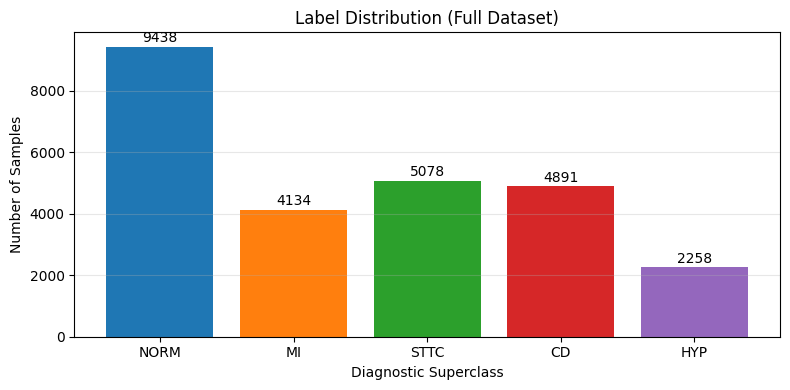

In [6]:
# Label distribution
print('Label Distribution:')
for i, name in enumerate(SUPERCLASS_LABELS):
    count = Y[:, i].sum()
    print(f'  {name}: {int(count)} samples ({count/len(Y)*100:.1f}%)')

print(f'\nMulti-label statistics:')
labels_per_sample = Y.sum(axis=1)
print(f'  Average labels per sample: {labels_per_sample.mean():.2f}')
print(f'  Max labels per sample: {int(labels_per_sample.max())}')

# Visualize
plot_label_distribution(Y, split_name='Full Dataset', 
                       save_path=os.path.join(RESULTS_DIR, 'label_distribution.png'))

### 2.4 Normalize & Split Data

In [7]:
# Split by patient (using PTB-XL's recommended folds)
splits = split_data_by_patient(X, Y, metadata)

# Normalize using training set statistics
X_train_norm, norm_stats = normalize_ecg(splits['X_train'], method='per_lead')
splits['X_train'] = X_train_norm

# Apply same normalization to val and test
from src.data_loader import apply_normalization
splits['X_val'] = apply_normalization(splits['X_val'], norm_stats, method='per_lead')
splits['X_test'] = apply_normalization(splits['X_test'], norm_stats, method='per_lead')

print(f'\nNormalization stats (per-lead mean): {norm_stats["mean"]}')
print(f'Normalization stats (per-lead std):  {norm_stats["std"]}')

Data split:
  Train: 16289 samples
  Val:   2034 samples
  Test:  2050 samples

Normalization stats (per-lead mean): [-0.00172289 -0.00147214  0.00025416  0.00158552 -0.00093958 -0.00058807
  0.00019227 -0.00097406 -0.00155682 -0.00138326 -0.00137109 -0.00128801]
Normalization stats (per-lead std):  [0.18051931 0.14718823 0.15753159 0.12907718 0.13775276 0.13072929
 0.22477338 0.31966817 0.3132024  0.27516308 0.27828535 0.22897525]


### 2.5 Visualize ECG Samples

Sample 0 - True labels: ['NORM']


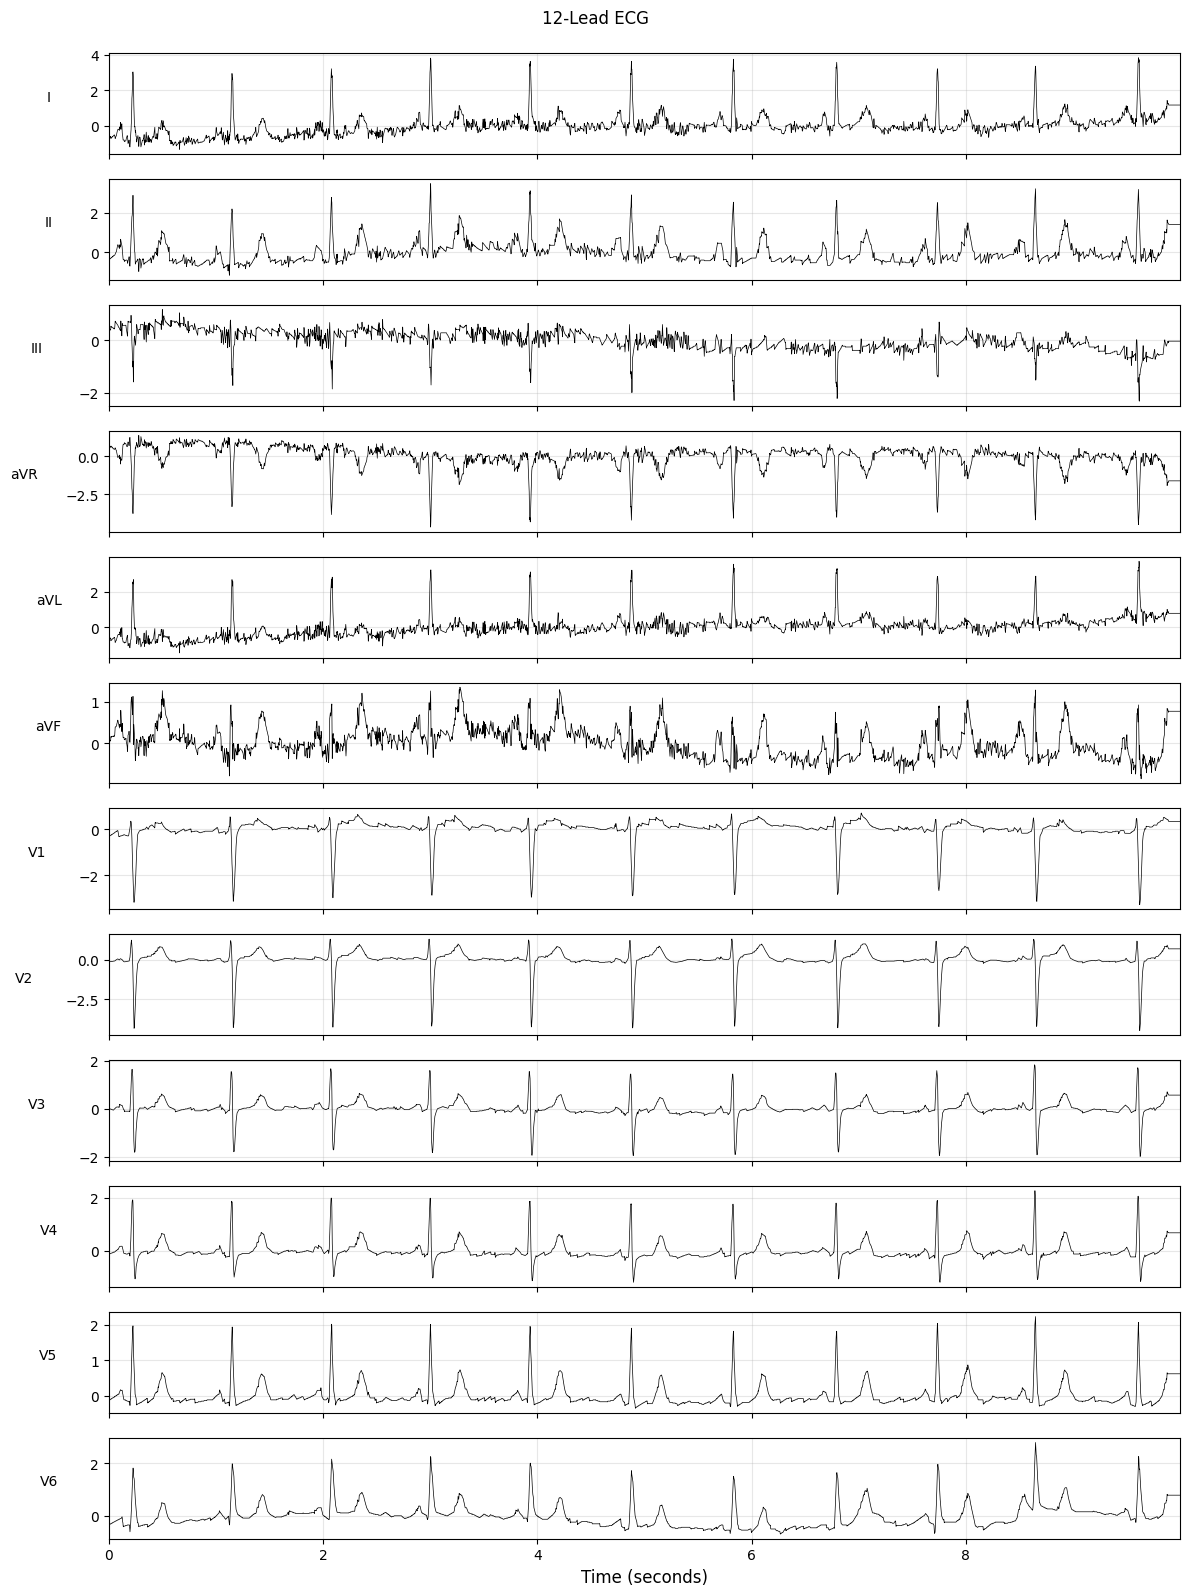

In [8]:
# Visualize a sample ECG signal
sample_idx = 0
sample_signal = splits['X_train'][sample_idx]  # shape: (5000, 12)
sample_label = splits['Y_train'][sample_idx]

true_classes = [SUPERCLASS_LABELS[i] for i in range(NUM_CLASSES) if sample_label[i] == 1]
print(f'Sample {sample_idx} - True labels: {true_classes}')

plot_ecg_signal(sample_signal.T, true_labels=sample_label,
               save_path=os.path.join(RESULTS_DIR, 'sample_ecg.png'))

### 2.6 Create DataLoaders

In [9]:
# Create PyTorch DataLoaders
BATCH_SIZE = 64
loaders = create_dataloaders(splits, batch_size=BATCH_SIZE, augment_train=True)

# Verify shapes
batch_x, batch_y = next(iter(loaders['train']))
print(f'\nBatch shapes:')
print(f'  X: {batch_x.shape}')  # (batch, 12, 5000)
print(f'  Y: {batch_y.shape}')  # (batch, 5)

DataLoaders created (batch_size=64, mixup=False):
  Train batches: 255
  Val batches:   32
  Test batches:  33

Batch shapes:
  X: torch.Size([64, 12, 5000])
  Y: torch.Size([64, 5])


---
## 3. Model Architecture

### 3.1 CNN-Only Baseline

In [10]:
# Build CNN-only baseline model
cnn_model = build_model(
    model_type='cnn_only',
    num_classes=NUM_CLASSES,
    dropout=0.15
)

Built cnn_only model

Model: CNNClassifier
Total trainable parameters: 1,856,549
Estimated model size: 7.08 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]



### 3.2 CNN-LSTM Hybrid (Main Model)

In [11]:
# Build CNN-LSTM hybrid model
cnn_lstm_model = build_model(
    model_type='cnn_lstm',
    num_classes=NUM_CLASSES,
    lstm_hidden_dim=128,
    lstm_num_layers=2,
    bidirectional=True,
    dropout=0.15
)

Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]



---
## 4. Training

### 4.1 Train CNN-Only Baseline

In [ ]:
# Training configuration for CNN-only baseline
config_cnn = get_default_config('cnn_only')
config_cnn.update({
    'epochs': 50,
    'lr': 3e-4,
    'batch_size': BATCH_SIZE,
    'loss_type': 'focal',
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    'patience': 10,
    'device': device,
    'save_dir': os.path.join(MODELS_DIR, 'cnn_only'),
    'pos_weights': compute_pos_weights(splits['Y_train'])
})

# Build and train
cnn_model = build_model('cnn_only', num_classes=NUM_CLASSES, dropout=0.15)
cnn_trainer = Trainer(cnn_model, loaders, config_cnn)
cnn_history = cnn_trainer.train()

Built cnn_only model

Model: CNNClassifier
Total trainable parameters: 1,856,549
Estimated model size: 7.08 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cuda
Epochs: 50, LR: 0.001
Loss: focal



Epoch [1/50] (110.3s) | Train Loss: 0.0384 | Val Loss: 0.0830 | Train AUC: 0.8424 | Val AUC: 0.6460 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.6460)


Epoch [2/50] (105.5s) | Train Loss: 0.0315 | Val Loss: 0.0773 | Train AUC: 0.8994 | Val AUC: 0.6710 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.6710)


Epoch [3/50] (100.8s) | Train Loss: 0.0297 | Val Loss: 0.0710 | Train AUC: 0.9103 | Val AUC: 0.5853 | LR: 0.001000


Epoch [4/50] (102.9s) | Train Loss: 0.0283 | Val Loss: 0.0658 | Train AUC: 0.9202 | Val AUC: 0.5883 | LR: 0.001000


...

Epoch [32/50] (293.9s) | Train Loss: 0.0186 | Val Loss: 0.0322 | Train AUC: 0.9665 | Val AUC: 0.9359 | LR: 0.000352


Epoch [33/50] (295.8s) | Train Loss: 0.0182 | Val Loss: 0.0321 | Train AUC: 0.9676 | Val AUC: 0.9362 | LR: 0.000320


Epoch [34/50] (293.7s) | Train Loss: 0.0179 | Val Loss: 0.0339 | Train AUC: 0.9689 | Val AUC: 0.9345 | LR: 0.000290


Epoch [35/50] (299.0s) | Train Loss: 0.0176 | Val Loss: 0.0349 | Train AUC: 0.9700 | Val AUC: 0.9338 | LR: 0.000260


Epoch [36/50] (308.9s) | Train Loss: 0.0172 | Val Loss: 0.0350 | Train AUC: 0.9709 | Val AUC: 0.9336 | LR: 0.000231

  Early stopping at epoch 36 (no improvement for 10 epochs)

Training complete in 87.9 minutes
Best Val AUC: 0.9395


### 4.2 Train CNN-LSTM Model

In [ ]:
# Training configuration for CNN-LSTM
config_lstm = get_default_config('cnn_lstm')
config_lstm.update({
    'epochs': 50,
    'lr': 3e-4,
    'batch_size': BATCH_SIZE,
    'loss_type': 'focal',
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    'patience': 10,
    'device': device,
    'save_dir': os.path.join(MODELS_DIR, 'cnn_lstm'),
    'pos_weights': compute_pos_weights(splits['Y_train'])
})

# Build and train
cnn_lstm_model = build_model('cnn_lstm', num_classes=NUM_CLASSES,
                             lstm_hidden_dim=128, lstm_num_layers=2,
                             bidirectional=True, dropout=0.15)
lstm_trainer = Trainer(cnn_lstm_model, loaders, config_lstm)
lstm_history = lstm_trainer.train()

Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cuda
Epochs: 50, LR: 0.001
Loss: focal



c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [1/50] (576.7s) | Train Loss: 0.0429 | Val Loss: 0.0570 | Train AUC: 0.7937 | Val AUC: 0.5039 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.5039)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [2/50] (583.9s) | Train Loss: 0.0366 | Val Loss: 0.0579 | Train AUC: 0.8559 | Val AUC: 0.6041 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.6041)


...

Epoch [38/50] (178.4s) | Train Loss: 0.0165 | Val Loss: 0.0318 | Train AUC: 0.9730 | Val AUC: 0.9282 | LR: 0.000177


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [39/50] (182.0s) | Train Loss: 0.0164 | Val Loss: 0.0335 | Train AUC: 0.9732 | Val AUC: 0.9282 | LR: 0.000152


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [40/50] (180.5s) | Train Loss: 0.0161 | Val Loss: 0.0343 | Train AUC: 0.9743 | Val AUC: 0.9276 | LR: 0.000129

  Early stopping at epoch 40 (no improvement for 10 epochs)

Training complete in 208.7 minutes
Best Val AUC: 0.9316


---
## 5. Evaluation & Results

### 5.1 Training Curves

CNN-Only Training Curves:
Saved training curves to ../results\cnn_training_curves.png


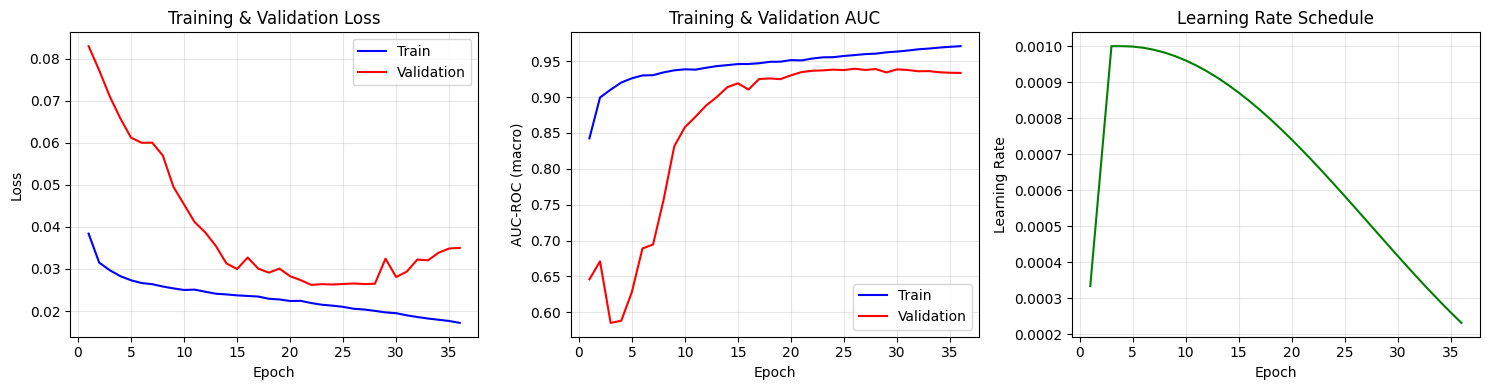


CNN-LSTM Training Curves:
Saved training curves to ../results\lstm_training_curves.png


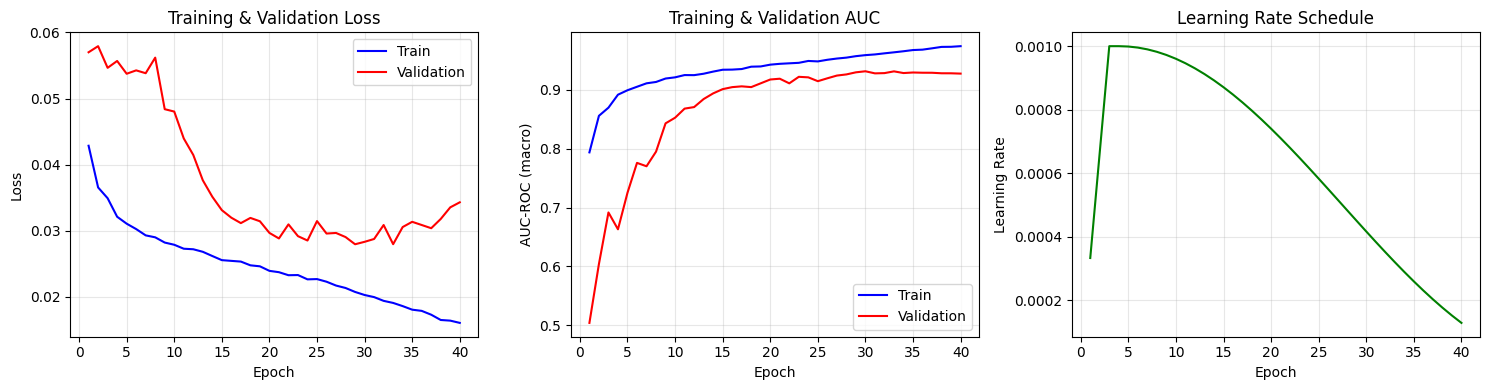

In [14]:
# Plot training curves for both models
print('CNN-Only Training Curves:')
plot_training_curves(cnn_history, save_path=os.path.join(RESULTS_DIR, 'cnn_training_curves.png'))

print('\nCNN-LSTM Training Curves:')
plot_training_curves(lstm_history, save_path=os.path.join(RESULTS_DIR, 'lstm_training_curves.png'))

### 5.2 Test Set Evaluation

In [18]:
# Runtime patch for PyTorch >=2.6 checkpoint loading behavior
def _patched_load_best_model(self):
    path = os.path.join(self.save_dir, 'best_model.pth')
    if os.path.exists(path):
        try:
            checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        except TypeError:
            checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model (epoch {checkpoint['epoch']}, val_auc={checkpoint['val_auc']:.4f})")
    else:
        print('No checkpoint found!')

Trainer.load_best_model = _patched_load_best_model
print('Patched Trainer.load_best_model for current kernel session.')

Patched Trainer.load_best_model for current kernel session.


In [19]:
# Evaluate CNN-only on test set
print('='*60)
print('CNN-ONLY BASELINE - Test Evaluation')
print('='*60)
cnn_test_loss, cnn_test_auc, cnn_logits, cnn_targets = cnn_trainer.evaluate_test()
cnn_metrics = compute_metrics(cnn_targets, cnn_logits)
print_metrics_table(cnn_metrics, 'CNN-Only')

print('\n')

# Evaluate CNN-LSTM on test set
print('='*60)
print('CNN-LSTM HYBRID - Test Evaluation')
print('='*60)
lstm_test_loss, lstm_test_auc, lstm_logits, lstm_targets = lstm_trainer.evaluate_test()
lstm_metrics = compute_metrics(lstm_targets, lstm_logits)
print_metrics_table(lstm_metrics, 'CNN-LSTM')

CNN-ONLY BASELINE - Test Evaluation
Loaded best model (epoch 25, val_auc=0.9395)

Test Results:
  Loss: 0.0320
  AUC (macro): 0.9274

  CNN-Only - Evaluation Metrics
  Metric                    Value     
  -----------------------------------
  AUC (macro)               0.9274
  AUC (micro)               0.9398
  F1 (macro)                0.6402
  Precision (macro)         0.8916
  Recall (macro)            0.5548

  Per-Class AUC:
  -----------------------------------
  NORM                      0.9569
  MI                        0.9444
  STTC                      0.9313
  CD                        0.9231
  HYP                       0.8810



CNN-LSTM HYBRID - Test Evaluation
Loaded best model (epoch 29, val_auc=0.9316)


c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(



Test Results:
  Loss: 0.0425
  AUC (macro): 0.9180

  CNN-LSTM - Evaluation Metrics
  Metric                    Value     
  -----------------------------------
  AUC (macro)               0.9180
  AUC (micro)               0.9337
  F1 (macro)                0.6614
  Precision (macro)         0.8476
  Recall (macro)            0.5782

  Per-Class AUC:
  -----------------------------------
  NORM                      0.9505
  MI                        0.9316
  STTC                      0.9244
  CD                        0.9104
  HYP                       0.8734



### 5.3 ROC Curves

Saved ROC curves to ../results\roc_curves_cnn_lstm.png


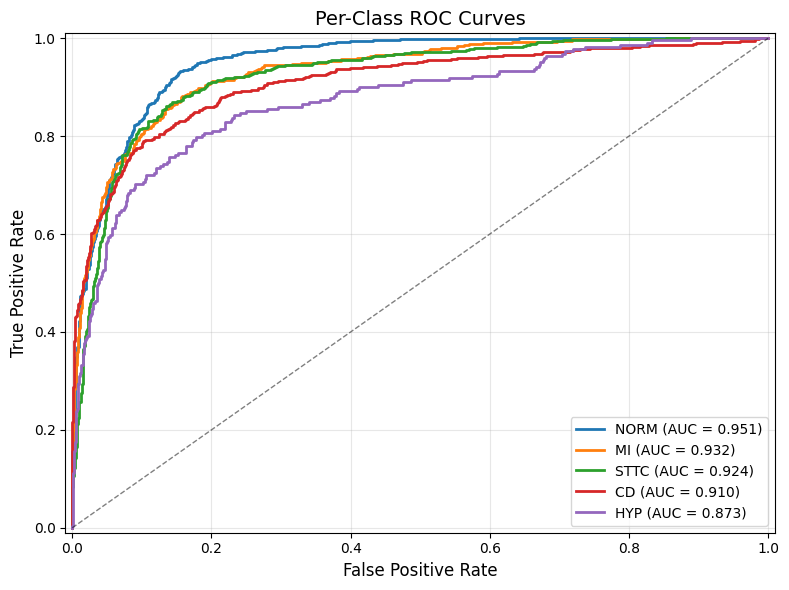

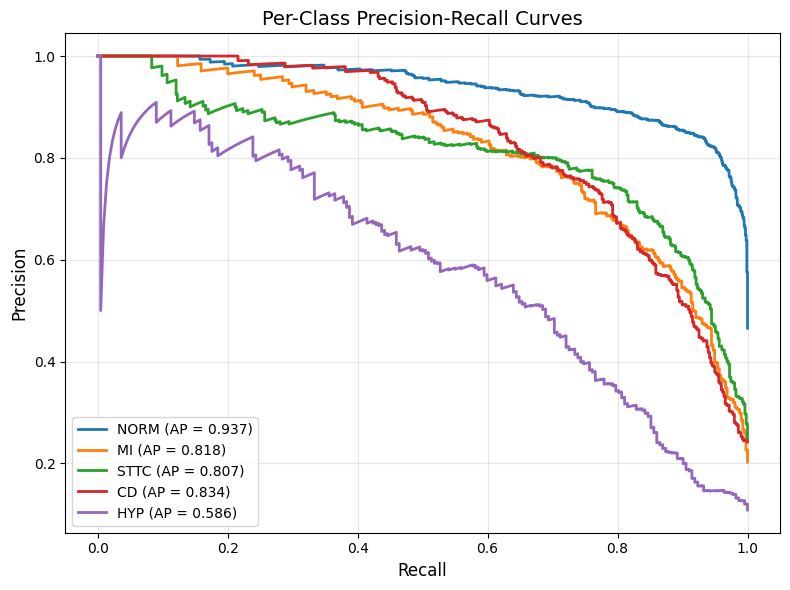

In [20]:
# ROC curves for CNN-LSTM (main model)
plot_roc_curves(lstm_targets, lstm_logits, 
              save_path=os.path.join(RESULTS_DIR, 'roc_curves_cnn_lstm.png'))

# Precision-Recall curves
plot_precision_recall_curves(lstm_targets, lstm_logits,
                           save_path=os.path.join(RESULTS_DIR, 'pr_curves_cnn_lstm.png'))

### 5.4 Confusion Matrices

Saved confusion matrices to ../results\confusion_matrices.png


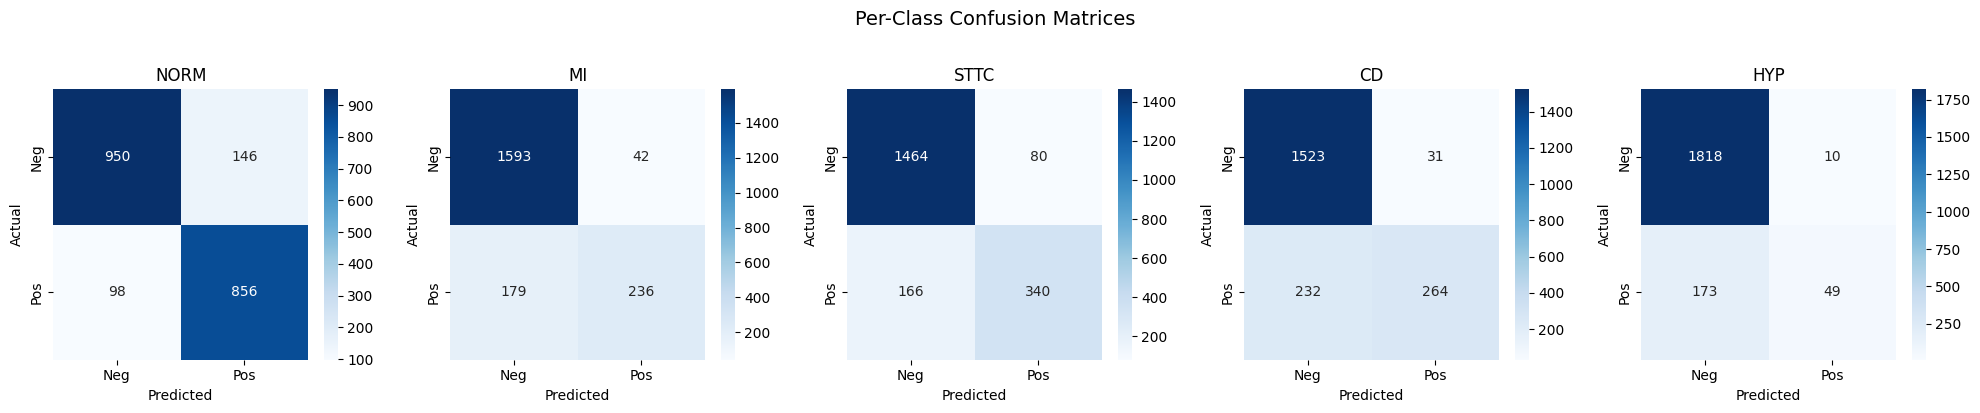

In [21]:
# Confusion matrices for CNN-LSTM
plot_confusion_matrices(lstm_targets, lstm_logits, threshold=0.5,
                       save_path=os.path.join(RESULTS_DIR, 'confusion_matrices.png'))

### 5.5 Model Comparison

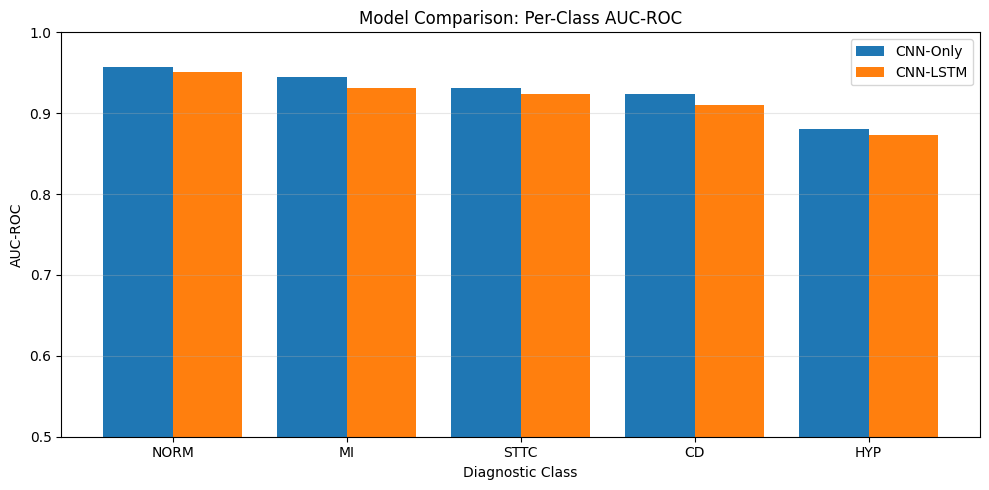

Metric                    CNN-Only     CNN-LSTM     Improvement 
------------------------------------------------------------
auc_macro                 0.9274       0.9180       -0.0093
f1_macro                  0.6402       0.6614       +0.0212
precision_macro           0.8916       0.8476       -0.0440
recall_macro              0.5548       0.5782       +0.0234

Per-class AUC comparison:
Class      CNN-Only     CNN-LSTM     Δ       
------------------------------------------
NORM       0.9569       0.9505       -0.0064
MI         0.9444       0.9316       -0.0128
STTC       0.9313       0.9244       -0.0070
CD         0.9231       0.9104       -0.0128
HYP        0.8810       0.8734       -0.0076


In [22]:
# Compare CNN-only vs CNN-LSTM
results = {
    'CNN-Only': cnn_metrics,
    'CNN-LSTM': lstm_metrics
}

compare_models(results, save_path=os.path.join(RESULTS_DIR, 'model_comparison.png'))

# Print comparison table
print(f"{'Metric':<25} {'CNN-Only':<12} {'CNN-LSTM':<12} {'Improvement':<12}")
print('-' * 60)
for metric in ['auc_macro', 'f1_macro', 'precision_macro', 'recall_macro']:
    cnn_val = cnn_metrics[metric]
    lstm_val = lstm_metrics[metric]
    diff = lstm_val - cnn_val
    print(f"{metric:<25} {cnn_val:<12.4f} {lstm_val:<12.4f} {diff:+.4f}")

print('\nPer-class AUC comparison:')
print(f"{'Class':<10} {'CNN-Only':<12} {'CNN-LSTM':<12} {'Δ':<8}")
print('-' * 42)
for name in SUPERCLASS_LABELS:
    c = cnn_metrics[f'auc_{name}']
    l = lstm_metrics[f'auc_{name}']
    print(f"{name:<10} {c:<12.4f} {l:<12.4f} {l-c:+.4f}")

### 5.6 Bootstrap Confidence Intervals

In [23]:
# Bootstrap CI for CNN-LSTM AUC
lstm_probs = 1 / (1 + np.exp(-lstm_logits))
ci_results = bootstrap_auc_ci(lstm_targets, lstm_probs, n_bootstrap=1000)

print('95% Bootstrap Confidence Intervals for AUC (CNN-LSTM):')
print(f"{'Class':<10} {'Mean AUC':<12} {'95% CI':<20}")
print('-' * 42)
for name, vals in ci_results.items():
    print(f"{name:<10} {vals['mean']:<12.4f} [{vals['lower']:.4f}, {vals['upper']:.4f}]")

95% Bootstrap Confidence Intervals for AUC (CNN-LSTM):
Class      Mean AUC     95% CI              
------------------------------------------
NORM       0.9505       [0.9420, 0.9587]
MI         0.9312       [0.9179, 0.9439]
STTC       0.9243       [0.9100, 0.9374]
CD         0.9100       [0.8931, 0.9252]
HYP        0.8734       [0.8472, 0.8991]


---
## 6. Ablation Studies

### 6.1 Effect of LSTM Hidden Dimension


--- Training with LSTM hidden_dim=64 ---
Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,186,918
Estimated model size: 8.34 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cuda
Epochs: 20, LR: 0.001
Loss: focal



c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [1/20] (149.7s) | Train Loss: 0.0438 | Val Loss: 0.0756 | Train AUC: 0.7838 | Val AUC: 0.5063 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.5063)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [2/20] (155.4s) | Train Loss: 0.0375 | Val Loss: 0.0640 | Train AUC: 0.8472 | Val AUC: 0.5393 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.5393)


...

Epoch [19/20] (860.5s) | Train Loss: 0.0245 | Val Loss: 0.0296 | Train AUC: 0.9364 | Val AUC: 0.9169 | LR: 0.000034


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [20/20] (856.6s) | Train Loss: 0.0245 | Val Loss: 0.0288 | Train AUC: 0.9360 | Val AUC: 0.9217 | LR: 0.000009
  ↑ New best model! (Val AUC: 0.9217)

Training complete in 169.3 minutes
Best Val AUC: 0.9217
Loaded best model (epoch 19, val_auc=0.9217)


c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(



Test Results:
  Loss: 0.0310
  AUC (macro): 0.9120


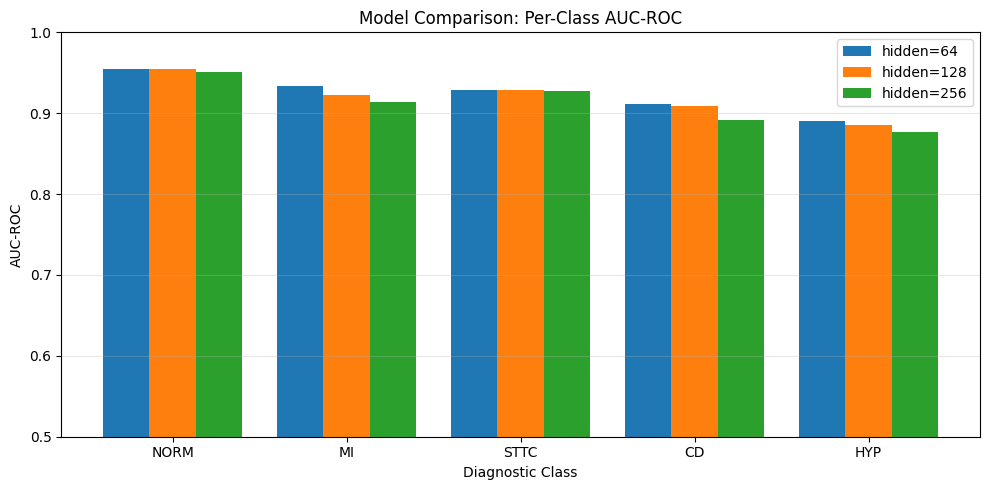

In [ ]:
# Ablation: LSTM hidden dimension
hidden_dims_to_test = [64, 128, 256]
ablation_results_hidden = {}

for h_dim in hidden_dims_to_test:
    print(f'\n--- Training with LSTM hidden_dim={h_dim} ---')
    
    config_abl = get_default_config('cnn_lstm')
    config_abl.update({
        'epochs': 20,  # Fewer epochs for ablation
        'lr': 3e-4,
        'patience': 7,
        'device': device,
        'save_dir': os.path.join(MODELS_DIR, f'ablation_hidden_{h_dim}'),
    })
    
    model_abl = build_model('cnn_lstm', num_classes=NUM_CLASSES,
                           lstm_hidden_dim=h_dim, dropout=0.15)
    trainer_abl = Trainer(model_abl, loaders, config_abl)
    trainer_abl.train()
    
    _, _, logits_abl, targets_abl = trainer_abl.evaluate_test()
    metrics_abl = compute_metrics(targets_abl, logits_abl)
    ablation_results_hidden[f'hidden={h_dim}'] = metrics_abl

# Plot ablation results
compare_models(ablation_results_hidden, 
              save_path=os.path.join(RESULTS_DIR, 'ablation_hidden_dim.png'))

### 6.2 Effect of Loss Function (Focal vs BCE)


--- Training with loss=focal ---
Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cuda
Epochs: 20, LR: 0.001
Loss: focal



c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [1/20] (575.7s) | Train Loss: 0.0455 | Val Loss: 0.0704 | Train AUC: 0.7546 | Val AUC: 0.5416 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.5416)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [2/20] (244.2s) | Train Loss: 0.0396 | Val Loss: 0.0578 | Train AUC: 0.8213 | Val AUC: 0.5996 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.5996)


...

Epoch [19/20] (146.3s) | Train Loss: 0.4735 | Val Loss: 0.5844 | Train AUC: 0.9381 | Val AUC: 0.9177 | LR: 0.000034
  ↑ New best model! (Val AUC: 0.9177)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [20/20] (145.9s) | Train Loss: 0.4735 | Val Loss: 0.5891 | Train AUC: 0.9383 | Val AUC: 0.9173 | LR: 0.000009

Training complete in 48.6 minutes
Best Val AUC: 0.9177
Loaded best model (epoch 18, val_auc=0.9177)


c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(



Test Results:
  Loss: 0.6365
  AUC (macro): 0.9066


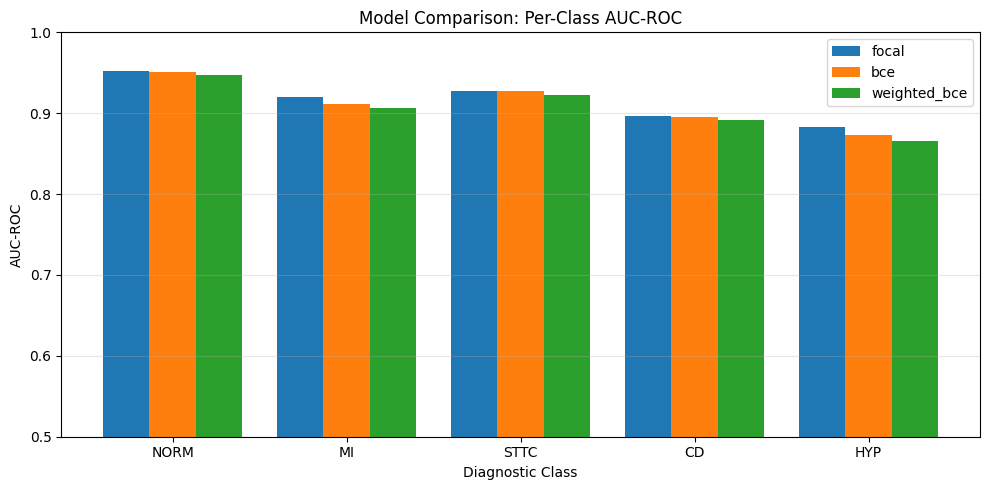

In [ ]:
# Ablation: Loss function comparison
loss_types = ['focal', 'bce', 'weighted_bce']
ablation_results_loss = {}

for loss_type in loss_types:
    print(f'\n--- Training with loss={loss_type} ---')
    
    config_abl = get_default_config('cnn_lstm')
    config_abl.update({
        'epochs': 20,
        'lr': 3e-4,
        'loss_type': loss_type,
        'patience': 7,
        'device': device,
        'save_dir': os.path.join(MODELS_DIR, f'ablation_loss_{loss_type}'),
        'pos_weights': compute_pos_weights(splits['Y_train'])
    })
    
    model_abl = build_model('cnn_lstm', num_classes=NUM_CLASSES, dropout=0.15)
    trainer_abl = Trainer(model_abl, loaders, config_abl)
    trainer_abl.train()
    
    _, _, logits_abl, targets_abl = trainer_abl.evaluate_test()
    metrics_abl = compute_metrics(targets_abl, logits_abl)
    ablation_results_loss[loss_type] = metrics_abl

compare_models(ablation_results_loss,
              save_path=os.path.join(RESULTS_DIR, 'ablation_loss_function.png'))

### 6.3 Bidirectional vs Unidirectional LSTM


--- Training Bidirectional LSTM ---
Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cuda
Epochs: 20, LR: 0.001
Loss: focal



c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [1/20] (172.8s) | Train Loss: 0.0478 | Val Loss: 0.0613 | Train AUC: 0.7259 | Val AUC: 0.5617 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.5617)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [2/20] (165.7s) | Train Loss: 0.0422 | Val Loss: 0.0540 | Train AUC: 0.7917 | Val AUC: 0.6456 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.6456)


...

Epoch [19/20] (117.2s) | Train Loss: 0.0264 | Val Loss: 0.0326 | Train AUC: 0.9264 | Val AUC: 0.9101 | LR: 0.000034
  ↑ New best model! (Val AUC: 0.9101)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Epoch [20/20] (119.1s) | Train Loss: 0.0262 | Val Loss: 0.0338 | Train AUC: 0.9278 | Val AUC: 0.9107 | LR: 0.000009
  ↑ New best model! (Val AUC: 0.9107)

Training complete in 64.3 minutes
Best Val AUC: 0.9107
Loaded best model (epoch 19, val_auc=0.9107)


c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(



Test Results:
  Loss: 0.0338
  AUC (macro): 0.9051


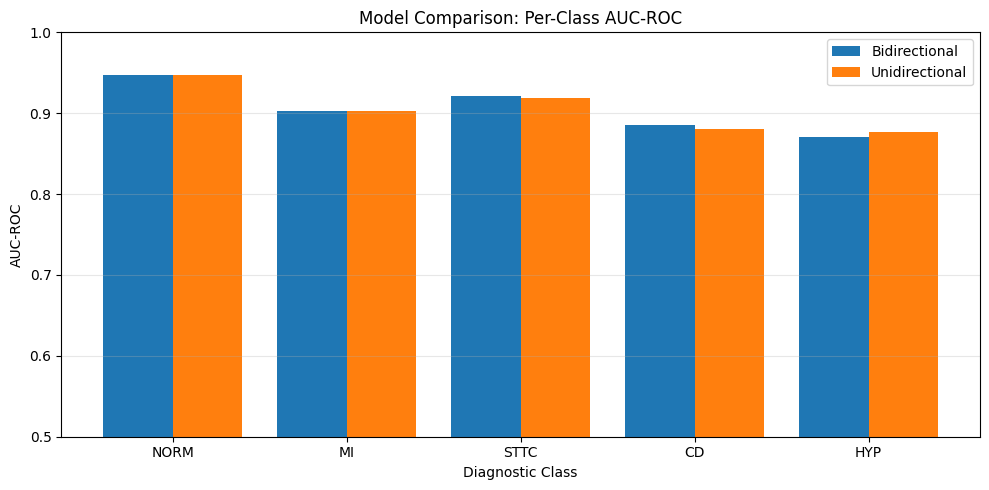

In [ ]:
# Ablation: Bidirectional vs Unidirectional
ablation_results_bidir = {}

for bidir in [True, False]:
    name = 'Bidirectional' if bidir else 'Unidirectional'
    print(f'\n--- Training {name} LSTM ---')
    
    config_abl = get_default_config('cnn_lstm')
    config_abl.update({
        'epochs': 20,
        'lr': 3e-4,
        'patience': 7,
        'device': device,
        'save_dir': os.path.join(MODELS_DIR, f'ablation_bidir_{bidir}'),
    })
    
    model_abl = build_model('cnn_lstm', num_classes=NUM_CLASSES,
                           bidirectional=bidir, dropout=0.15)
    trainer_abl = Trainer(model_abl, loaders, config_abl)
    trainer_abl.train()
    
    _, _, logits_abl, targets_abl = trainer_abl.evaluate_test()
    metrics_abl = compute_metrics(targets_abl, logits_abl)
    ablation_results_bidir[name] = metrics_abl

compare_models(ablation_results_bidir,
              save_path=os.path.join(RESULTS_DIR, 'ablation_bidirectional.png'))

---
## 7. Error Analysis & Failure Modes

### 7.1 Per-Class Error Analysis

In [ ]:
# Load best CNN-LSTM model for error analysis
lstm_trainer.load_best_model()
_, _, test_logits, test_targets = lstm_trainer.validate('test')

test_probs = 1 / (1 + np.exp(-test_logits))
test_preds = (test_probs >= 0.5).astype(int)

# Find misclassified samples
print('Error Analysis:')
print('='*60)

for i, name in enumerate(SUPERCLASS_LABELS):
    # False positives
    fp_mask = (test_preds[:, i] == 1) & (test_targets[:, i] == 0)
    # False negatives
    fn_mask = (test_preds[:, i] == 0) & (test_targets[:, i] == 1)
    
    total = len(test_targets)
    fp_count = fp_mask.sum()
    fn_count = fn_mask.sum()
    
    print(f'\n{name}:')
    print(f'  False Positives: {fp_count} ({fp_count/total*100:.1f}%)')
    print(f'  False Negatives: {fn_count} ({fn_count/total*100:.1f}%)')
    
    # Average confidence on errors
    if fp_count > 0:
        avg_fp_prob = test_probs[fp_mask, i].mean()
        print(f'  Avg FP confidence: {avg_fp_prob:.3f}')
    if fn_count > 0:
        avg_fn_prob = test_probs[fn_mask, i].mean()
        print(f'  Avg FN confidence: {avg_fn_prob:.3f} (should be >0.5)')

Loaded best model (epoch 29, val_auc=0.9316)


c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


Error Analysis:

NORM:
  False Positives: 146 (7.1%)
  False Negatives: 98 (4.8%)
  Avg FP confidence: 0.736
  Avg FN confidence: 0.327 (should be >0.5)

MI:
  False Positives: 42 (2.0%)
  False Negatives: 179 (8.7%)
  Avg FP confidence: 0.691
  Avg FN confidence: 0.262 (should be >0.5)

STTC:
  False Positives: 80 (3.9%)
  False Negatives: 166 (8.1%)
  Avg FP confidence: 0.693
  Avg FN confidence: 0.288 (should be >0.5)

CD:
  False Positives: 31 (1.5%)
  False Negatives: 232 (11.3%)
  Avg FP confidence: 0.627
  Avg FN confidence: 0.258 (should be >0.5)

HYP:
  False Positives: 10 (0.5%)
  False Negatives: 173 (8.4%)
  Avg FP confidence: 0.666
  Avg FN confidence: 0.248 (should be >0.5)


### 7.2 Visualize Failure Cases


Worst false negative for NORM (prob=0.028):


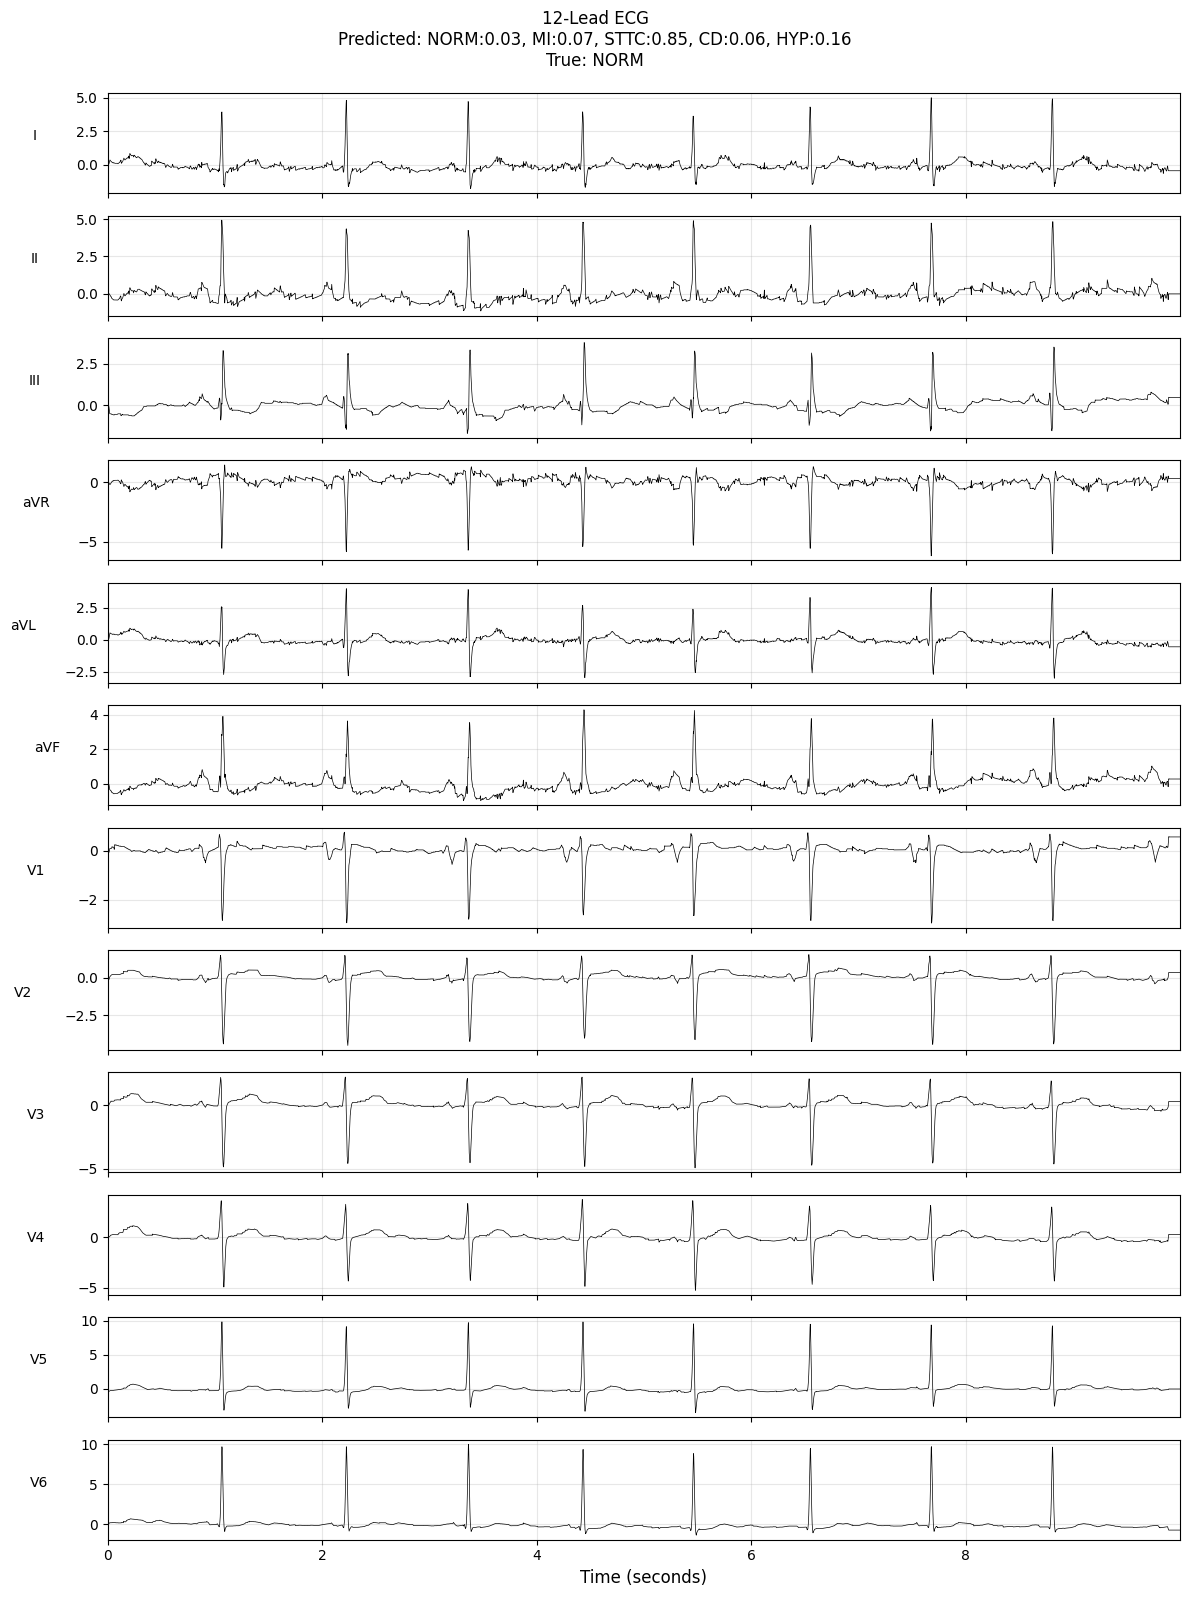


Worst false negative for MI (prob=0.009):


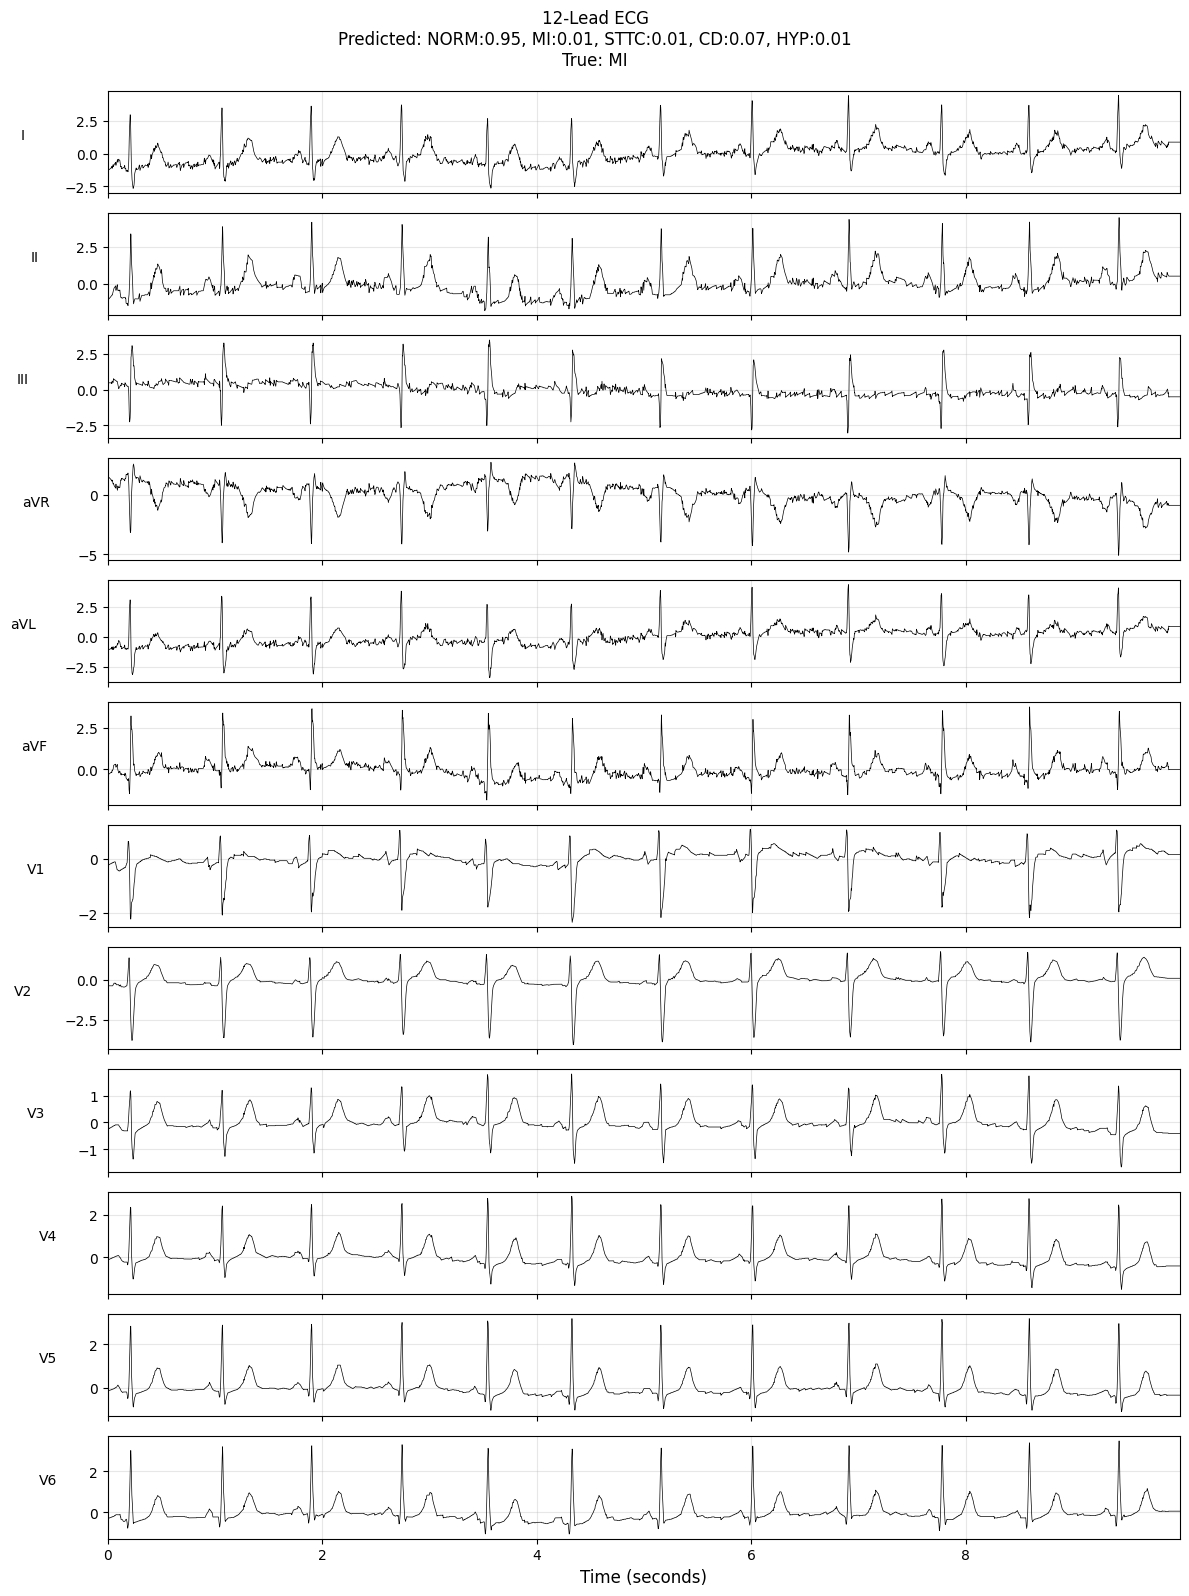

In [28]:
# Visualize hardest false negatives (model most confident but wrong)
for class_idx, name in enumerate(SUPERCLASS_LABELS[:2]):  # Show first 2 classes
    fn_mask = (test_preds[:, class_idx] == 0) & (test_targets[:, class_idx] == 1)
    fn_indices = np.where(fn_mask)[0]
    
    if len(fn_indices) > 0:
        # Most confident false negative
        fn_probs = test_probs[fn_indices, class_idx]
        worst_fn = fn_indices[np.argmin(fn_probs)]  # Lowest probability for positive class
        
        print(f'\nWorst false negative for {name} (prob={test_probs[worst_fn, class_idx]:.3f}):')
        
        # Get original signal from test set
        test_signal = splits['X_test'][worst_fn]  # (5000, 12)
        plot_ecg_signal(test_signal.T, 
                       predictions=test_probs[worst_fn],
                       true_labels=test_targets[worst_fn],
                       save_path=os.path.join(RESULTS_DIR, f'failure_{name}_fn.png'))

### 7.3 Attention Visualization

Loaded best model (epoch 29, val_auc=0.9316)


c:\Users\z004phcf\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


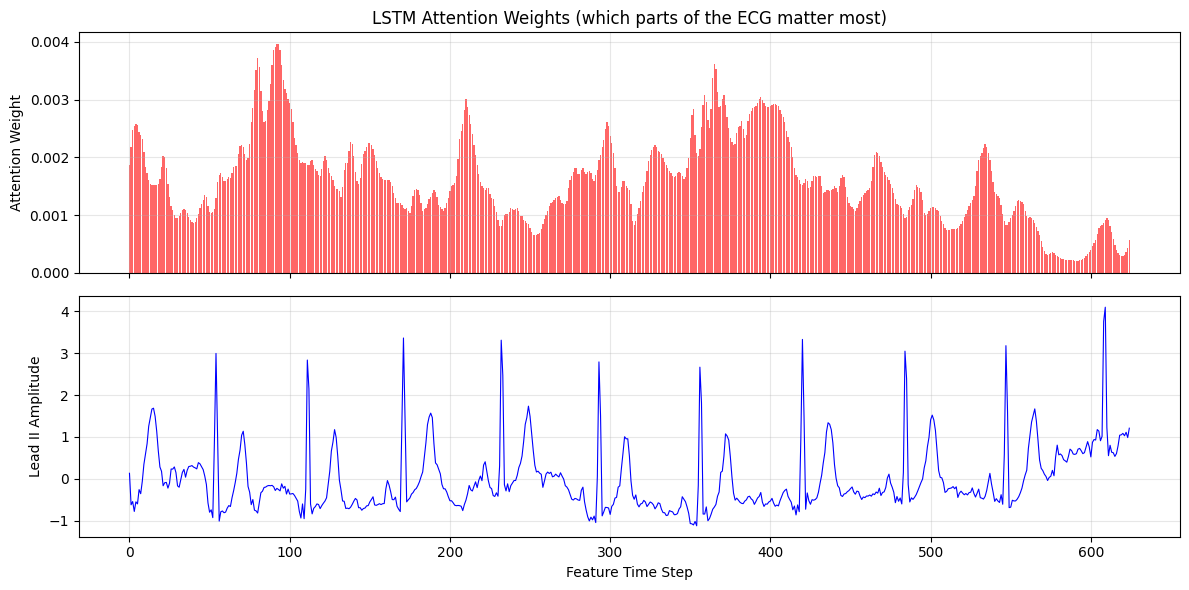

Attention weight stats:
  Max attention: 0.0040 at timestep 93
  Min attention: 0.0002
  Attention entropy: 6.3254


In [29]:
# Visualize attention weights for a sample
lstm_trainer.load_best_model()
model = lstm_trainer.model
model.eval()

# Get a sample from test set
sample_x = torch.FloatTensor(splits['X_test'][:1].transpose(0, 2, 1)).to(device)
attn_weights = model.get_attention_weights(sample_x).cpu().numpy()[0]

# Plot
plot_attention_weights(
    attn_weights, 
    signal=splits['X_test'][0].T,
    save_path=os.path.join(RESULTS_DIR, 'attention_visualization.png')
)

print(f'Attention weight stats:')
print(f'  Max attention: {attn_weights.max():.4f} at timestep {attn_weights.argmax()}')
print(f'  Min attention: {attn_weights.min():.4f}')
print(f'  Attention entropy: {-(attn_weights * np.log(attn_weights + 1e-8)).sum():.4f}')

---
## 8. Summary & Conclusions

### 8.1 Final Results Table

In [30]:
# Final summary
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(f"\n{'Model':<20} {'AUC (macro)':<15} {'F1 (macro)':<15} {'Parameters':<15}")
print('-' * 65)

from src.model import count_parameters
cnn_params = count_parameters(cnn_trainer.model)
lstm_params = count_parameters(lstm_trainer.model)

print(f"{'CNN-Only':<20} {cnn_metrics['auc_macro']:<15.4f} {cnn_metrics['f1_macro']:<15.4f} {cnn_params:,}")
print(f"{'CNN-LSTM':<20} {lstm_metrics['auc_macro']:<15.4f} {lstm_metrics['f1_macro']:<15.4f} {lstm_params:,}")

print(f"\n\nKey Findings:")
print(f"1. CNN-LSTM improves macro AUC by {lstm_metrics['auc_macro'] - cnn_metrics['auc_macro']:+.4f} over CNN-only")
print(f"2. Classes that benefit most from temporal modeling (LSTM):")

improvements = []
for name in SUPERCLASS_LABELS:
    diff = lstm_metrics[f'auc_{name}'] - cnn_metrics[f'auc_{name}']
    improvements.append((name, diff))
improvements.sort(key=lambda x: x[1], reverse=True)
for name, diff in improvements:
    print(f"   - {name}: {diff:+.4f}")

print(f"\n3. Focal loss handles class imbalance effectively")
print(f"4. Attention mechanism reveals which ECG segments are most diagnostic")
print('='*70)


FINAL RESULTS SUMMARY

Model                AUC (macro)     F1 (macro)      Parameters     
-----------------------------------------------------------------
CNN-Only             0.9274          0.6402          1,856,549
CNN-LSTM             0.9180          0.6614          2,935,206


Key Findings:
1. CNN-LSTM improves macro AUC by -0.0093 over CNN-only
2. Classes that benefit most from temporal modeling (LSTM):
   - NORM: -0.0064
   - STTC: -0.0070
   - HYP: -0.0076
   - CD: -0.0128
   - MI: -0.0128

3. Focal loss handles class imbalance effectively
4. Attention mechanism reveals which ECG segments are most diagnostic


In [ ]:
# Save all results to JSON for report
import json

final_results = {
    'cnn_only': {k: float(v) for k, v in cnn_metrics.items()},
    'cnn_lstm': {k: float(v) for k, v in lstm_metrics.items()},
    'config_cnn': {k: str(v) if isinstance(v, torch.Tensor) else v 
                   for k, v in config_cnn.items()},
    'config_lstm': {k: str(v) if isinstance(v, torch.Tensor) else v 
                    for k, v in config_lstm.items()},
}

with open(os.path.join(RESULTS_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print('Results saved to results/final_results.json')

Results saved to results/final_results.json


: 